# Slide Dump

### Methods II — Feature Analysis, Modeling & Evaluation *(revised section)*

**Symbolic feature extraction**
- Pitch histogram and interval distribution per motif
- N-gram extraction (uni/bi/trigram) — per-song and corpus-level
- Contour representation (Up/Down/Same directional encoding)

**Motif analysis & classification**
- Feature vector construction for motif-level similarity (cosine/KL)
- PCA/UMAP motif clustering visualization
- Baseline classification — Logistic Regression, SVM (motif identity from symbolic features)
- Confusion matrix analysis across motif classes

**Conditioned symbolic generation**

*Statistical baselines*
- N-gram language model (bigram/trigram) with Laplace smoothing
- Markov chain generation conditioned on motif class

*LSTM (implemented)*
- Autoregressive LSTM language model trained per motif class
- Fragment-conditioned: input seed fragment → model continues from bar 1
- Vocabulary: slot-based pitch/rest tokens (~50 types)
- Hyperparameter ablation: seq_len (16 vs 32 slots), temperature sweep (T=0.8–1.3)
- Trained independently per motif (เขมร, ลาว) to model intra-style distributions

*Transformer (planned)*
- Self-attention over the full token sequence — no recency bias
- Positional encoding adapted for bar-aligned slot structure
- Expected advantage: long-range phrase dependency (A–A–B–B structure)

*Mamba (planned)*
- State-space model with selective memory — efficient alternative to attention
- Handles longer sequences with lower memory cost than Transformer
- Will probe whether structured state transitions better capture repetitive Thai phrase cycles

**Evaluation**
- N-gram overlap — single-song and corpus-level (2/3/4-gram)
- Pitch KL divergence, repetition score, segment decay, rest chi-squared
- Cross-model comparison on same motif/seed/temperature settings
- Expert-informed listening evaluation

## Detailed Summary — Future Improvements with More Data

---

### 🔧 Preprocessing

**Current limitations:**
- Fixed 32-slot windows with no overlap → small dataset, loses phrase boundary context
- Motif labels assigned manually at song level, not phrase level
- No augmentation — each song contributes a fixed number of fragments

**With more data + better preprocessing:**
- **Sliding window with stride** — overlapping windows (e.g., stride=8) multiply training examples by 4× without new recordings
- **Phrase-boundary-aware segmentation** — instead of fixed slots, segment at natural cadence points (สามชั้น phrase cycles end predictably); this teaches the model structurally complete units rather than arbitrary cuts
- **Pitch transposition augmentation** — Thai classical pieces are often performed in different registers; transposing each fragment ±1–2 semitones within the scale dramatically increases data without changing stylistic identity
- **Motif sub-labelling** — currently เขมร/ลาว are monolithic labels; with more data, sub-label by section type (สามชั้น/สองชั้น/ชั้นเดียว) and train conditioned on both motif + tier → finer-grained stylistic control
- **Rest token normalisation** — short rests vs long rests currently distinct tokens; consolidating to duration classes may reduce vocab sparsity

---

### 🧠 LSTM

**Current limitations:**
- seq_len=16 = ~half a bar of context; model can't see how a phrase opened when deciding how to close it
- Trained independently per motif → no shared melodic vocabulary across styles
- Single autoregressive head → no explicit phrase-structure awareness

**With more data + improved LSTM:**
- **Longer context (seq_len=32–64)** — the seq_len ablation shows seq_len=32 already slightly improves KL and REST; with more data to support longer sequences, the model can condition on full 1–2 bar contexts and learn proper phrase closure patterns
- **Hierarchical LSTM** — two-level architecture: a bar-level LSTM encodes each bar into a latent vector; a phrase-level LSTM conditions generation on the last N bar vectors → directly models A–A–B–B repetition structure
- **Multi-motif training with style token** — train one model on all motifs, inject a motif embedding at the start of each sequence; the shared backbone learns common Thai melodic grammar while style tokens specialise for each motif. Better generalisation, fewer data requirements per style
- **Scheduled sampling** — during training, sometimes feed the model's own predictions instead of ground truth tokens; reduces the train/inference distribution mismatch that causes phrase drift

---

### ⚡ Transformer

**Why it fits Thai classical music:**
Thai classical structure is fundamentally **positional and periodic** — the สามชั้น tier cycles phrases every 32 beats, สองชั้น every 16, ชั้นเดียว every 8. A Transformer with full self-attention can directly attend to the phrase-opening tokens when generating phrase-closing tokens — something LSTM structurally cannot do.

**Concrete improvements expected:**
- **Repetition score** — the biggest gap currently (best model: 0.56 vs corpus reference 0.77). Transformer attention over the full sequence can learn to copy/vary the opening phrase, directly closing this gap
- **Long-range corpus overlap** — seg_decay currently drops slightly toward the end of sequences; attention doesn't decay, so late-bar quality should be maintained
- **Bar-aligned positional encoding** — replace standard sinusoidal PE with bar-position encoding (slot 0–31 within bar + bar index within phrase); teaches the model the cyclical metric structure explicitly
- **With more data:** Transformers are data-hungry; current corpus size likely makes them prone to overfitting. With 3–5× more songs, a 4–6 layer Transformer with ~4M parameters becomes viable

---

### 🌀 Mamba / MusicMamba

**Why consider it:**
Mamba is a state-space model (SSM) — it maintains a compressed hidden state that selectively retains information from the full past sequence, without the $O(n^2)$ memory cost of attention. For **long Thai pieces** (สามชั้น can be 100+ bars), this is practical where full attention is not.

**MusicMamba specifically** (if adapted to symbolic music):
- Designed for audio SSM but the selective state mechanism maps naturally to symbolic tokens — the state "remembers" which pitches have been emphasised, which phrases have been played, and gates new information accordingly
- **Repetition score improvement** — the selective memory can be tuned to retain phrase-opening patterns and gate them into later bars; explicitly models the A–A–B–B cycling without needing explicit bar-position encoding
- **REST χ² improvement** — SSM state can track rest density over the last N bars and modulate rest probability; N-gram currently beats LSTM on this, and Mamba's memory architecture is better suited to tracking such distributional running statistics than LSTM
- **With more data:** SSMs are more parameter-efficient than Transformers; Mamba can generalise well even at moderate data scales, making it a good candidate for Thai music where corpus size will always be limited compared to general music datasets

---

## Short Version for Slides

---

**Slide: "Where We Go From Here"**

| Component | Current | Improvement | Expected Gain |
|---|---|---|---|
| **Preprocessing** | Fixed 32-slot windows, song-level labels | Stride windows + augmentation + phrase-boundary cuts | 3–5× more training examples, cleaner phrase units |
| **LSTM** | seq_len=16, per-motif silo | Hierarchical LSTM + multi-motif training + longer context | Better phrase closure, cross-style transfer |
| **Transformer** | Not yet implemented | Bar-aligned PE + full self-attention | Directly models A–A–B–B repetition structure — closes the 0.50→0.77 repetition gap |
| **Mamba** | Not yet implemented | Selective SSM memory over full piece | Phrase cycling without quadratic attention cost; better REST/pitch tracking |

**One-liner:** *"LSTM proves a learned model works. Transformer adds phrase-level memory. Mamba makes that memory efficient enough for full pieces. More data makes all three viable."*

Here's an expanded version with concrete UX thinking built from what your system actually does:

---

## End-User Application: Thai Classical Music Composition System

---

### 1️⃣ Intelligent Archive & Retrieval Assistant

Users input a short melodic fragment → system finds the closest matches in the corpus using vector/n-gram similarity.

**User-facing controls:**
- **Motif filter** — restrict search to a style family (เขมร / ลาว / พม่า / มอญ etc.) or search across all
- **Match strictness** — exact n-gram match vs fuzzy pitch-contour match (tolerates octave transposition)
- **Result count** — top 3 / top 10 / show all above threshold
- **Sort by** — similarity score, song name, section type (สามชั้น / สองชั้น / ชั้นเดียว)

**Output:**
- Side-by-side notation of query vs retrieved phrases
- Source attribution (song name, section, bar range)
- Option to "use this as seed" → pass directly into the generative tool

---

### 2️⃣ Generative Composition Tool

**Core parameters the user controls:**

| Parameter | What it does | Suggested UI |
|-----------|-------------|--------------|
| **Temperature** (0.8–1.3) | Lower = closer to training data, more repetitive. Higher = more variety, more risk of drift | Slider: *Conservative ↔ Creative* |
| **Seed / fragment** | Starting phrase the model continues from | Text input or pick from archive |
| **Output length** | How many bars to generate | Dropdown: 2 / 4 / 8 / 16 bars |
| **Style lock** | Force generation to stay within one motif's vocabulary | Toggle: Free / Locked to เขมร / ลาว / etc. |
| **Variants** | Generate N independent continuations from same seed | A/B/C compare buttons (3–5 variants) |

**Advanced controls (power users):**
- **Context window** — how many preceding tokens the model conditions on (seq_len 16 = half-bar, 32 = full bar). Exposed as *"Memory depth: Short / Full bar / Extended"*
- **Rest density** — bias the sampling toward/away from rest tokens (controls rhythmic density)
- **Pitch range lock** — constrain output to a register (e.g., mid-octave only, useful for specific instruments)

---

### 3️⃣ Hybrid Workflow (the most powerful mode)

The real value is chaining both systems:



In [ ]:
User fragment
    ↓
[Archive] → show 3 historically grounded continuations
    ↓
[Generative] → show 3 model-generated continuations
    ↓
User picks one (or mixes bars from both)
    ↓
Use that output as the new seed → iterate



This gives a **"composer's assistant"** feel — not fully automatic, not fully manual. The user stays in creative control while the system provides options grounded in both history and learned patterns.

---

### 4️⃣ Additional Feature Ideas

**Expansion mode** (your "3–4 bars → full piece" idea)
- Input: a very short traditional fragment (even 1–2 bars)
- System generates a สามชั้น / สองชั้น / ชั้นเดียว structure around it
- Each tier generated at different temperatures (สามชั้น=1.1 for variety, ชั้นเดียว=0.8 for tight cadence)

**Style transfer / motif remapping**
- Take a ลาว melody → regenerate it "in the style of เขมร"
- Done by retraining/fine-tuning or by switching the corpus-based retrieval filter

**Quality gate** (automatic)
- After generation, auto-run `corpus_overlap` and `repetition_score` in the background
- If corpus_overlap < 0.85 → warn user *"This output may have drifted from the style — try lowering temperature"*
- If repetition_score < 0.3 → warn *"Low phrase repetition — may sound fragmented"*

**Export**
- Symbolic notation (JSON / MusicXML)
- MIDI via your existing `midi_ranad.py`
- Rendered score (via LilyPond or similar)

---

The key design principle: **temperature should never be exposed as a raw number to casual users** — label it as a dial from *Traditional* → *Experimental* with maybe 5 stops, and only show the actual 0.8–1.3 range in an "advanced" panel.

/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_60301/2728019120.py:134: UserWarning: Glyph 128220 (\N{SCROLL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_60301/2728019120.py:134: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_60301/2728019120.py:134: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_60301/2728019120.py:134: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/var/folders/ns/3kxdm2j954q34sf6464cfn700000gn/T/ipykernel_60301/2728019120.py:134: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(pad=0.3)
/var/folders/ns/3kxdm2j954q34sf6464cfn

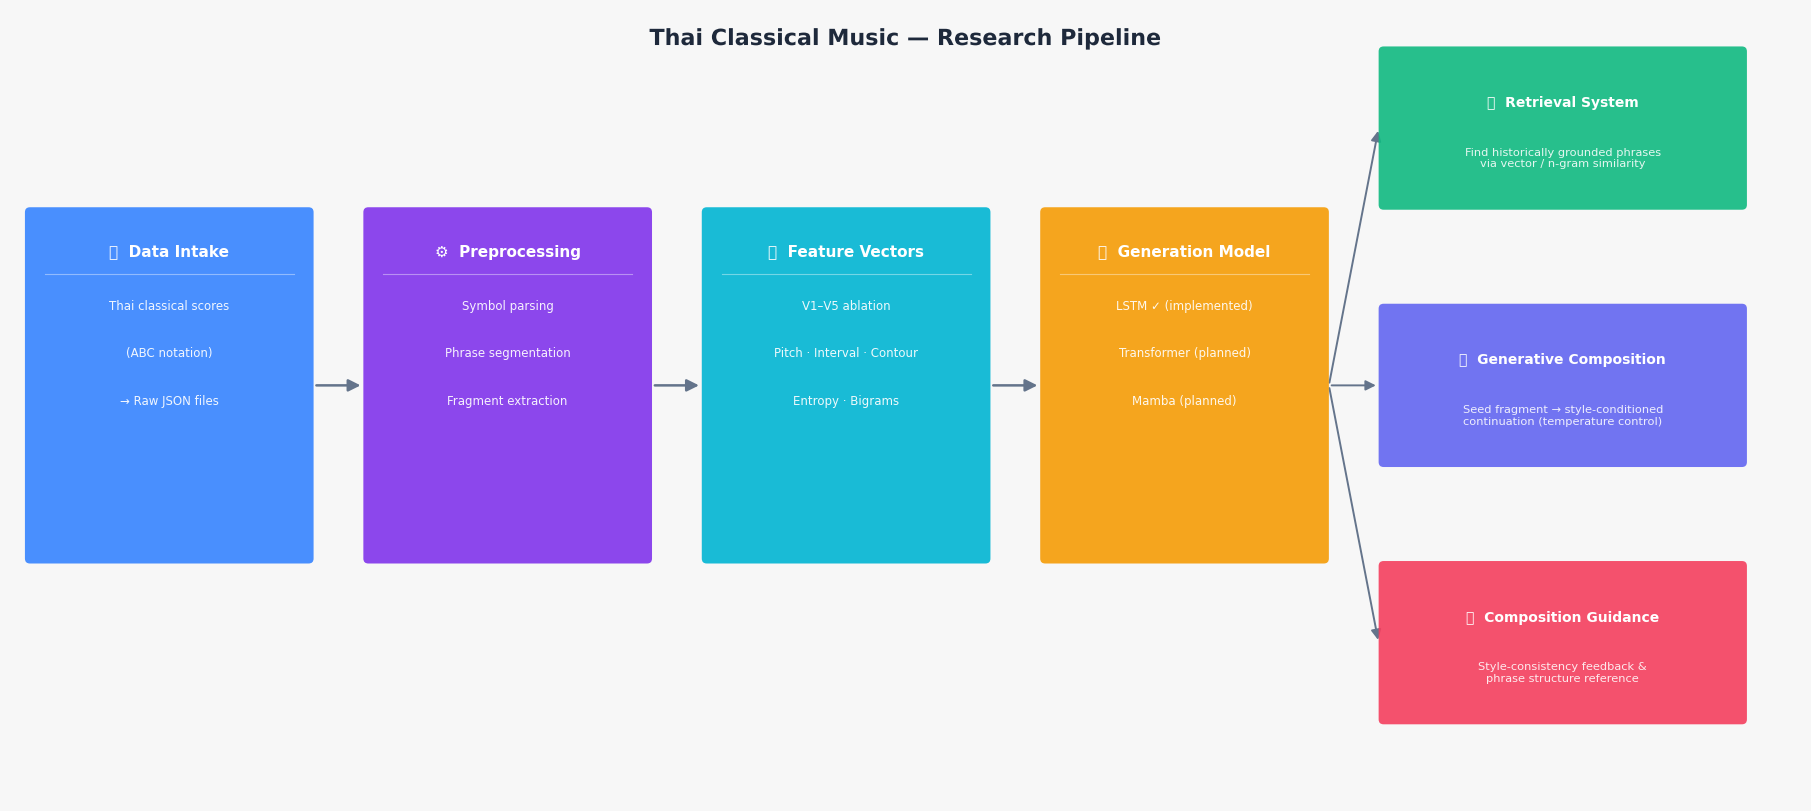

Saved → pipeline_diagram.png


In [1]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe

# ── Layout constants ──────────────────────────────────────────────────────────
FW, FH = 18, 8
fig, ax = plt.subplots(figsize=(FW, FH))
ax.set_xlim(0, FW)
ax.set_ylim(0, FH)
ax.axis("off")
fig.patch.set_facecolor("#F7F7F7")

# ── Color palette ─────────────────────────────────────────────────────────────
C = {
    "intake":  "#3A86FF",
    "preproc": "#8338EC",
    "feat":    "#06B6D4",
    "model":   "#F59E0B",
    "ret":     "#10B981",
    "gen":     "#6366F1",
    "guide":   "#F43F5E",
    "arrow":   "#64748B",
    "bg":      "#F7F7F7",
}

# ── Helper: rounded box with title + bullet lines ─────────────────────────────
def draw_box(ax, cx, cy, w, h, color, title, bullets, icon=""):
    box = FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.05", linewidth=0,
        facecolor=color, alpha=0.92, zorder=3,
    )
    ax.add_patch(box)
    # Title
    ax.text(cx, cy + h/2 - 0.32, f"{icon}  {title}" if icon else title,
            ha="center", va="top", fontsize=11, fontweight="bold",
            color="white", zorder=4)
    # Divider line
    ax.plot([cx - w/2 + 0.15, cx + w/2 - 0.15],
            [cy + h/2 - 0.62, cy + h/2 - 0.62],
            color="white", alpha=0.4, lw=0.8, zorder=4)
    # Bullets
    for i, line in enumerate(bullets):
        ax.text(cx, cy + h/2 - 0.88 - i * 0.48, line,
                ha="center", va="top", fontsize=8.5,
                color="white", alpha=0.92, zorder=4)

# ── Helper: horizontal arrow between two boxes ───────────────────────────────
def draw_arrow(ax, x_start, x_end, y):
    ax.annotate("", xy=(x_end, y), xytext=(x_start, y),
                arrowprops=dict(arrowstyle="-|>", color=C["arrow"],
                                lw=1.8, mutation_scale=18),
                zorder=2)

# ── Helper: arrow from right edge of modeling box to left of app box ─────────
def draw_branch_arrow(ax, x_start, x_end, y_start, y_end):
    ax.annotate("", xy=(x_end, y_end), xytext=(x_start, y_start),
                arrowprops=dict(arrowstyle="-|>", color=C["arrow"],
                                lw=1.5, mutation_scale=16,
                                connectionstyle="arc3,rad=0.0"),
                zorder=2)

# ── Pipeline stage positions (cx, cy, w, h) ───────────────────────────────────
BOX_H = 3.5
PIPE_Y = 4.2

stages = [
    # (cx,   cy,     w,    h,       color,        title,              icon, bullets)
    (1.6,  PIPE_Y, 2.8,  BOX_H,  C["intake"],  "Data Intake",      "📜",
        ["Thai classical scores", "(ABC notation)", "→ Raw JSON files"]),

    (5.0,  PIPE_Y, 2.8,  BOX_H,  C["preproc"], "Preprocessing",    "⚙️",
        ["Symbol parsing", "Phrase segmentation", "Fragment extraction"]),

    (8.4,  PIPE_Y, 2.8,  BOX_H,  C["feat"],    "Feature Vectors",  "📊",
        ["V1–V5 ablation", "Pitch · Interval · Contour", "Entropy · Bigrams"]),

    (11.8, PIPE_Y, 2.8,  BOX_H,  C["model"],   "Generation Model", "🤖",
        ["LSTM ✓ (implemented)", "Transformer (planned)", "Mamba (planned)"]),
]

for cx, cy, w, h, color, title, icon, bullets in stages:
    draw_box(ax, cx, cy, w, h, color, title, bullets, icon)

# ── Arrows between pipeline stages ───────────────────────────────────────────
stage_rights = [cx + w/2 for cx, _, w, *_ in stages]
stage_lefts  = [cx - w/2 for cx, _, w, *_ in stages]
for i in range(len(stages) - 1):
    draw_arrow(ax, stage_rights[i] + 0.05, stage_lefts[i+1] - 0.05, PIPE_Y)

# ── Application boxes (right side fan-out) ────────────────────────────────────
APP_W, APP_H = 3.6, 1.55
APP_X = 15.6
app_configs = [
    (APP_X, 6.8, C["ret"],   "🔍  Retrieval System",
     "Find historically grounded phrases\nvia vector / n-gram similarity"),
    (APP_X, 4.2, C["gen"],   "🎵  Generative Composition",
     "Seed fragment → style-conditioned\ncontinuation (temperature control)"),
    (APP_X, 1.6, C["guide"], "📚  Composition Guidance",
     "Style-consistency feedback &\nphrase structure reference"),
]

for cx, cy, color, title, sub in app_configs:
    box = FancyBboxPatch(
        (cx - APP_W/2, cy - APP_H/2), APP_W, APP_H,
        boxstyle="round,pad=0.05", linewidth=0,
        facecolor=color, alpha=0.90, zorder=3,
    )
    ax.add_patch(box)
    ax.text(cx, cy + 0.26, title, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white", zorder=4)
    ax.text(cx, cy - 0.30, sub, ha="center", va="center",
            fontsize=8.2, color="white", alpha=0.88, zorder=4)

# ── Branch arrows from modeling box right-edge to each app box ───────────────
model_cx, model_cy, model_w = 11.8, PIPE_Y, 2.8
mx_right = model_cx + model_w / 2

for cx, cy, *_ in app_configs:
    ax.annotate("", xy=(cx - APP_W/2 - 0.05, cy),
                xytext=(mx_right + 0.05, PIPE_Y),
                arrowprops=dict(arrowstyle="-|>", color=C["arrow"],
                                lw=1.4, mutation_scale=15,
                                connectionstyle="arc3,rad=0.0"),
                zorder=2)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.text(FW / 2, 7.7, "Thai Classical Music — Research Pipeline",
        ha="center", va="center", fontsize=16, fontweight="bold",
        color="#1E293B",
        path_effects=[pe.withStroke(linewidth=3, foreground="#F7F7F7")])

plt.tight_layout(pad=0.3)
plt.savefig("pipeline_diagram.png", dpi=180, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → pipeline_diagram.png")


Here's the full pipeline as a reference you can use anywhere:

---

## Thai Classical Music Research Pipeline

### Left-to-right pipeline (4 stages)

**① Data Intake** `[blue]`
- Thai classical scores in ABC notation (hand-transcribed / digitised)
- Each song parsed into a raw JSON file with symbol sequences
- Motif labels assigned manually (ลาว / เขมร / แขก / etc.)

**② Preprocessing** `[purple]`
- Symbol tokenisation (pitch tokens + REST tokens, ~50 vocab types)
- Phrase segmentation (bar-aligned, slot-based)
- Fragment extraction — 32-slot sliding windows, no overlap, rest threshold filter

**③ Feature Vectors (V1–V5)** `[teal]`
- **V1** — Pitch histogram (10D) + Interval histogram (10D) = 20D
- **V2** — V1 + Directional interval stats (Up/Same/Down ratios) = 23D
- **V3** — V2 + Interval entropy = 24D
- **V4** — V3 + Pitch class entropy = 25D
- **V5** — V4 + Top-K bigram counts = 40D
- Used for both classification and generation conditioning

**④ Generation Model** `[amber]`
- **LSTM** ✓ — autoregressive, trained per motif class, temperature-controlled
- **Transformer** (planned) — full self-attention, bar-aligned positional encoding
- **Mamba** (planned) — state-space model, efficient for long phrase cycles

---

### Right fan-out (3 applications)

**🔍 Retrieval System** `[green]`
- User inputs a short melodic fragment
- System returns closest corpus matches via cosine / n-gram similarity
- Output: side-by-side notation, source attribution, option to pass to generator

**🎵 Generative Composition Tool** `[indigo]`
- User picks a seed fragment + style (motif class) + temperature
- Model generates a continuation (2 / 4 / 8 / 16 bars)
- Multiple variants (A/B/C compare) from same seed

**📚 Composition Guidance** `[pink/red]`
- Style-consistency feedback after generation (corpus overlap score)
- Phrase structure reference (สามชั้น / สองชั้น / ชั้นเดียว patterns)
- Warns if output drifts from style ("try lowering temperature")

---

### Connecting arrow logic


In [ ]:
[Intake] → [Preprocessing] → [Feature Vectors] → [Generation Model]
                                                          ↗ Retrieval
                                                          → Generative Composition  
                                                          ↘ Composition Guidance



---

### Design notes if you're building in Figma / Canva / PowerPoint

| Box | Suggested fill | Text colour |
|---|---|---|
| Data Intake | `#3A86FF` | white |
| Preprocessing | `#8338EC` | white |
| Feature Vectors | `#06B6D4` | white |
| Generation Model | `#F59E0B` | white |
| Retrieval | `#10B981` | white |
| Generative Composition | `#6366F1` | white |
| Composition Guidance | `#F43F5E` | white |
| Background | `#F7F7F7` | — |
| Arrows | `#64748B` | — |

- **Rounded corners** (8–12px) on all boxes
- Arrow heads pointing right for pipeline, branching out to the right for applications
- Keep font consistent — something like **Inter** or **Nunito** works well for slides

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings("ignore")

# ── Thai font ─────────────────────────────────────────────────────────────────
import pathlib
_FONT_PATH = pathlib.Path("thsarabunnew-webfont.ttf.1")
if _FONT_PATH.exists():
    fm.fontManager.addfont(str(_FONT_PATH))
    _THAI_FONT = fm.FontProperties(fname=str(_FONT_PATH)).get_name()
    plt.rcParams["font.family"] = _THAI_FONT
else:
    _THAI_FONT = "DejaVu Sans"
    print("⚠️  Thai font not found — Thai labels may not render correctly")

# ── Load all 5 CSVs ───────────────────────────────────────────────────────────
ROOT = pathlib.Path("thai_music_data")

df_kn   = pd.read_csv(ROOT / "batch_eval_results_khmer_ngram.csv")    # เขมร N-gram
df_kl16 = pd.read_csv(ROOT / "batch_eval_results_khmer_16_30.csv")    # เขมร LSTM-16
df_kl32 = pd.read_csv(ROOT / "batch_eval_results_khmer_32.csv")       # เขมร LSTM-32
df_ln   = pd.read_csv(ROOT / "batch_eval_results_laos_ngram.csv")     # ลาว N-gram
df_ll16 = pd.read_csv(ROOT / "batch_eval_results_laos_16_30.csv")     # ลาว LSTM-16

# ── Metric definitions ────────────────────────────────────────────────────────
METRICS = ["corpus_overlap", "seg_decay_mean", "single_overlap",
           "pitch_kl", "repetition_score", "rest_chi2"]
METRIC_LABELS = {
    "corpus_overlap":    "Corpus Overlap ↑",
    "seg_decay_mean":    "Seg Decay ↑",
    "single_overlap":    "Single Overlap ↑",
    "pitch_kl":          "Pitch KL ↓",
    "repetition_score":  "Repetition ↑",
    "rest_chi2":         "REST χ² ↓",
}
HIGHER_BETTER = {"corpus_overlap", "seg_decay_mean", "single_overlap", "repetition_score"}
LOWER_BETTER  = {"pitch_kl", "rest_chi2"}

# ── Canonical hyperparams ─────────────────────────────────────────────────────
CANON_T     = 1.0
CANON_N     = 3
CANON_ALPHA = 0.01

# ── Helper: filter to canonical setting, return mean±std across all rows ──────
def canonical_stats(df, model_type="lstm", temp=None, n=None, alpha=None):
    d = df.copy()
    if model_type == "lstm":
        d = d[d["temperature"] == temp]
    else:
        d = d[(d["n"] == n) & (d["alpha"] == alpha)]
    rows = []
    for m in METRICS:
        rows.append({"metric": m, "mean": d[m].mean(), "std": d[m].std(ddof=1)})
    return pd.DataFrame(rows).set_index("metric")

stats = {
    "เขมร N-gram":   canonical_stats(df_kn,  "ngram", n=CANON_N,  alpha=CANON_ALPHA),
    "เขมร LSTM-16":  canonical_stats(df_kl16, "lstm",  temp=CANON_T),
    "เขมร LSTM-32":  canonical_stats(df_kl32, "lstm",  temp=CANON_T),
    "ลาว N-gram":    canonical_stats(df_ln,  "ngram", n=CANON_N,  alpha=CANON_ALPHA),
    "ลาว LSTM-16":   canonical_stats(df_ll16, "lstm",  temp=CANON_T),
}

for name, s in stats.items():
    print(f"{'─'*50}")
    print(f"  {name}")
    for m in METRICS:
        arrow = "↑" if m in HIGHER_BETTER else "↓"
        print(f"    {m:<20s}: {s.loc[m,'mean']:.4f} ± {s.loc[m,'std']:.4f}  {arrow}")
print(f"{'─'*50}")
print("✅ All datasets loaded")

──────────────────────────────────────────────────
  เขมร N-gram
    corpus_overlap      : 0.9139 ± 0.0333  ↑
    seg_decay_mean      : 0.9149 ± 0.0361  ↑
    single_overlap      : 0.8118 ± 0.0324  ↑
    pitch_kl            : 0.0912 ± 0.0873  ↓
    repetition_score    : 0.4631 ± 0.0226  ↑
    rest_chi2           : 0.0205 ± 0.0100  ↓
──────────────────────────────────────────────────
  เขมร LSTM-16
    corpus_overlap      : 0.9573 ± 0.0379  ↑
    seg_decay_mean      : 0.9598 ± 0.0357  ↑
    single_overlap      : 0.8351 ± 0.0542  ↑
    pitch_kl            : 0.1030 ± 0.0970  ↓
    repetition_score    : 0.5008 ± 0.0518  ↑
    rest_chi2           : 0.0274 ± 0.0273  ↓
──────────────────────────────────────────────────
  เขมร LSTM-32
    corpus_overlap      : 0.9333 ± 0.0422  ↑
    seg_decay_mean      : 0.9362 ± 0.0420  ↑
    single_overlap      : 0.8272 ± 0.0479  ↑
    pitch_kl            : 0.0822 ± 0.0847  ↓
    repetition_score    : 0.4828 ± 0.0354  ↑
    rest_chi2           : 0.0322 ± 0.0

### Table 1 — Grand Canonical Comparison (4 models)

Canonical settings: **N-gram** → n=3, α=0.01 | **LSTM** → seq_len=16, T=1.0

Mean ± std across all songs × sections × seeds.  
🟢 = best in column among the 4 main models | Bold = best value

In [12]:
# ── Build grand summary table (4 main models) ────────────────────────────────
MAIN_MODELS = ["เขมร N-gram", "เขมร LSTM-16", "ลาว N-gram", "ลาว LSTM-16"]

rows = {}
for model in MAIN_MODELS:
    s = stats[model]
    row = {}
    for m in METRICS:
        row[METRIC_LABELS[m]] = f"{s.loc[m,'mean']:.4f} ± {s.loc[m,'std']:.3f}"
    rows[model] = row

grand_table = pd.DataFrame(rows).T
grand_table.index.name = "Model"

# ── Numeric version for highlighting ─────────────────────────────────────────
means_df = pd.DataFrame(
    {model: {m: stats[model].loc[m, "mean"] for m in METRICS} for model in MAIN_MODELS}
).T
means_df.index.name = "Model"

def highlight_best(s, metric_name):
    m_key = {v: k for k, v in METRIC_LABELS.items()}[s.name] if s.name in METRIC_LABELS.values() else s.name
    if m_key in HIGHER_BETTER:
        best_idx = s.idxmax()
    else:
        best_idx = s.idxmin()
    return ["background-color: #d4edda; font-weight: bold" if i == best_idx else "" for i in s.index]

# Style the display table
styled = (
    grand_table.style
    .set_caption("Grand Canonical Comparison — Mean ± Std")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"), ("padding", "8px 0")]},
        {"selector": "th", "props": [("background-color", "#2c3e50"), ("color", "white"), ("padding", "6px 10px"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "5px 12px"), ("text-align", "center"), ("font-size", "13px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f9f9f9")]},
        {"selector": "tr:hover", "props": [("background-color", "#eef2ff")]},
    ])
    .apply(lambda col: [
        "background-color: #d4edda; font-weight: bold"
        if (col.name in HIGHER_BETTER and means_df.loc[idx, col.name] == means_df[col.name].max()) or
           (col.name in LOWER_BETTER  and means_df.loc[idx, col.name] == means_df[col.name].min())
        else ""
        for idx in means_df.index
    ], subset=METRICS)
)

# Also show as clean printout
print("=" * 90)
print(f"{'Model':<18s}  " + "  ".join(f"{METRIC_LABELS[m]:<20s}" for m in METRICS))
print("=" * 90)
for model in MAIN_MODELS:
    s = stats[model]
    vals = "  ".join(f"{s.loc[m,'mean']:.4f} ± {s.loc[m,'std']:.3f}       " for m in METRICS)
    print(f"{model:<18s}  {vals}")
print("=" * 90)

grand_table

Model               Corpus Overlap ↑      Seg Decay ↑           Single Overlap ↑      Pitch KL ↓            Repetition ↑          REST χ² ↓           
เขมร N-gram         0.9139 ± 0.033         0.9149 ± 0.036         0.8118 ± 0.032         0.0912 ± 0.087         0.4631 ± 0.023         0.0205 ± 0.010       
เขมร LSTM-16        0.9573 ± 0.038         0.9598 ± 0.036         0.8351 ± 0.054         0.1030 ± 0.097         0.5008 ± 0.052         0.0274 ± 0.027       
ลาว N-gram          0.9078 ± 0.025         0.9073 ± 0.029         0.7929 ± 0.020         0.0288 ± 0.028         0.5172 ± 0.030         0.0112 ± 0.005       
ลาว LSTM-16         0.9311 ± 0.040         0.9321 ± 0.040         0.8038 ± 0.047         0.0626 ± 0.020         0.5633 ± 0.041         0.0201 ± 0.014       


,Corpus Overlap ↑,Seg Decay ↑,Single Overlap ↑,Pitch KL ↓,Repetition ↑,REST χ² ↓
Model,,,,,,
เขมร N-gram,0.9139 ± 0.033,0.9149 ± 0.036,0.8118 ± 0.032,0.0912 ± 0.087,0.4631 ± 0.023,0.0205 ± 0.010
เขมร LSTM-16,0.9573 ± 0.038,0.9598 ± 0.036,0.8351 ± 0.054,0.1030 ± 0.097,0.5008 ± 0.052,0.0274 ± 0.027
ลาว N-gram,0.9078 ± 0.025,0.9073 ± 0.029,0.7929 ± 0.020,0.0288 ± 0.028,0.5172 ± 0.030,0.0112 ± 0.005
ลาว LSTM-16,0.9311 ± 0.040,0.9321 ± 0.040,0.8038 ± 0.047,0.0626 ± 0.020,0.5633 ± 0.041,0.0201 ± 0.014


In [7]:
import pandas as pd
import jinja2
print(pd.__version__, jinja2.__version__)

2.2.3 3.0.3


In [5]:
!pip -q install -U "jinja2>=3.1.2"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataprep 0.4.5 requires jinja2<3.1,>=3.0, but you have jinja2 3.1.6 which is incompatible.
dataprep 0.4.5 requires pandas<2.0,>=1.1, but you have pandas 2.2.3 which is incompatible.
dataprep 0.4.5 requires pydantic<2.0,>=1.6, but you have pydantic 2.10.6 which is incompatible.
spacy-transformers 1.3.4 requires transformers<4.37.0,>=3.4.0, but you have transformers 4.45.2 which is incompatible.
torchvision 0.17.2 requires torch==2.2.2, but you have torch 2.1.0 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip


### Figure 1 — Temperature Sweep (LSTM, both motifs)

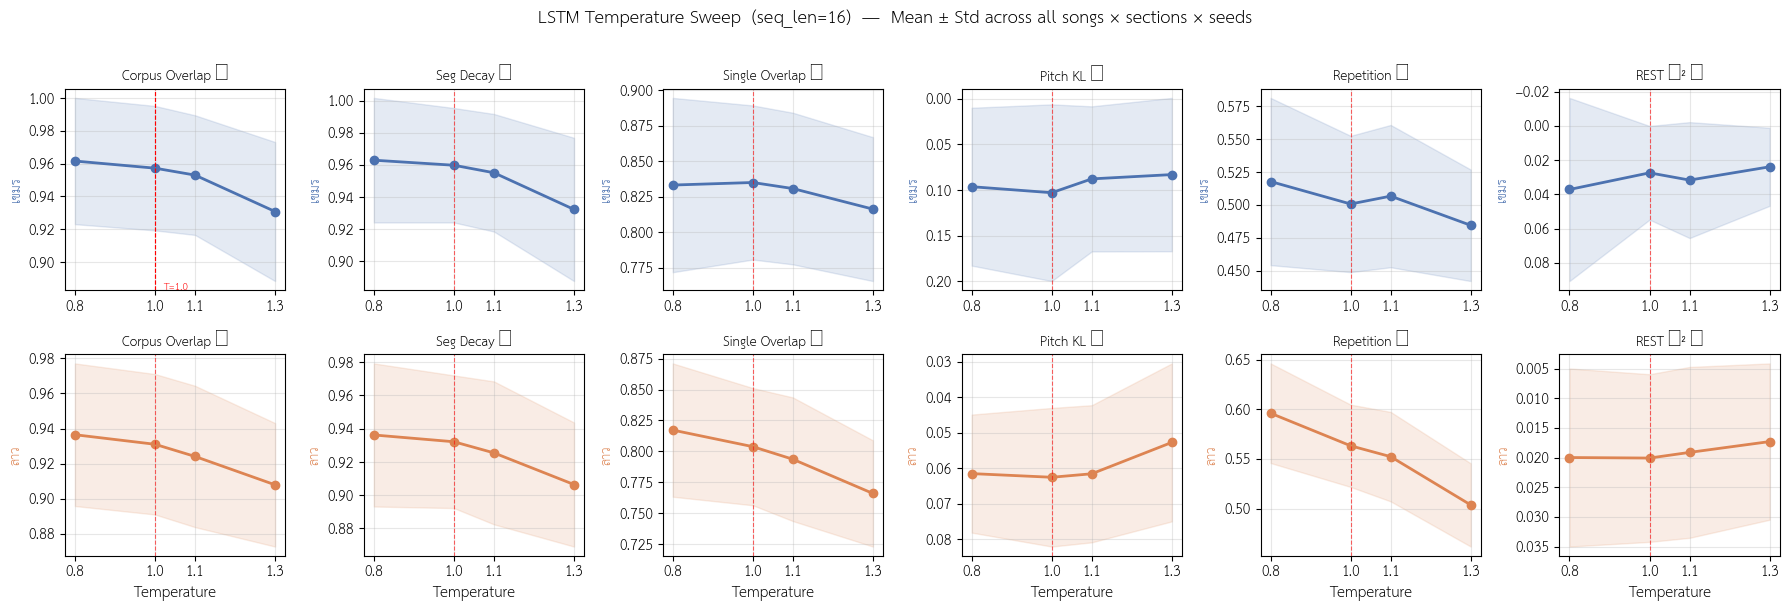

✅ Saved → fig_lstm_temp_sweep.png


In [13]:
def plot_sweep_lstm(df, motif_label, ax_row, temps=None, color="#4C72B0"):
    """Plot mean±std for each metric across temperature sweep."""
    if temps is None:
        temps = sorted(df["temperature"].unique())
    grp   = df.groupby("temperature")[METRICS]
    means = grp.mean()
    stds  = grp.std(ddof=1).fillna(0)
    for idx, m in enumerate(METRICS):
        ax = ax_row[idx]
        mu  = means[m].values
        sig = stds[m].values
        ax.plot(temps, mu, marker="o", linewidth=2, color=color)
        ax.fill_between(temps, mu - sig, mu + sig, alpha=0.15, color=color)
        ax.axvline(1.0, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="T=1.0")
        ax.set_title(METRIC_LABELS[m], fontsize=9)
        ax.set_xticks(temps)
        ax.grid(alpha=0.3)
        if m in LOWER_BETTER:
            ax.invert_yaxis()

fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharey=False)
fig.suptitle("LSTM Temperature Sweep  (seq_len=16)  —  Mean ± Std across all songs × sections × seeds",
             fontsize=12, fontweight="bold", y=1.01)

plot_sweep_lstm(df_kl16, "เขมร", axes[0], color="#4C72B0")
plot_sweep_lstm(df_ll16, "ลาว",   axes[1], color="#DD8452")

for j, m in enumerate(METRICS):
    axes[0][j].set_ylabel("เขมร", fontsize=9, color="#4C72B0")
    axes[1][j].set_ylabel("ลาว",   fontsize=9, color="#DD8452")
    axes[1][j].set_xlabel("Temperature")

# Vertical T=1.0 annotation on first panel
axes[0][0].axvline(1.0, color="red", linestyle="--", linewidth=0.8)
axes[0][0].text(1.02, axes[0][0].get_ylim()[0], "T=1.0", color="red", fontsize=7)

plt.tight_layout()
plt.savefig("fig_lstm_temp_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_lstm_temp_sweep.png")

### Figure 2 — Alpha (α) Sweep (N-gram, n=3, both motifs)

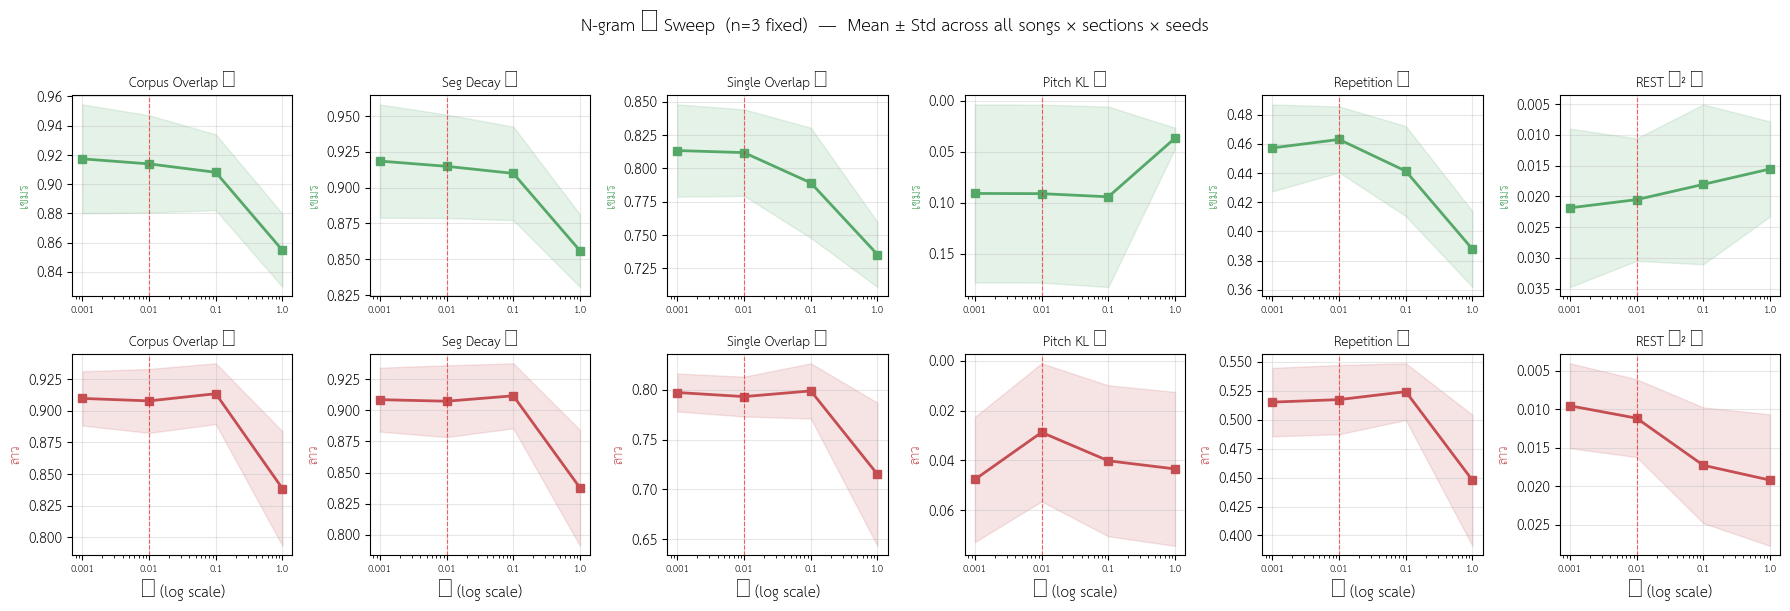

✅ Saved → fig_ngram_alpha_sweep.png


In [19]:
def plot_sweep_ngram_alpha(df, ax_row, n_fixed=3, color="#55A868"):
    """Plot mean±std for each metric across alpha sweep (fixed n)."""
    d = df[df["n"] == n_fixed]
    alphas = sorted(d["alpha"].unique())
    grp   = d.groupby("alpha")[METRICS]
    means = grp.mean()
    stds  = grp.std(ddof=1).fillna(0)
    for idx, m in enumerate(METRICS):
        ax = ax_row[idx]
        mu  = means[m].values
        sig = stds[m].values
        ax.semilogx(alphas, mu, marker="s", linewidth=2, color=color)
        ax.fill_between(alphas, mu - sig, mu + sig, alpha=0.15, color=color)
        ax.axvline(0.01, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="α=0.01")
        ax.set_title(METRIC_LABELS[m], fontsize=9)
        ax.set_xticks(alphas)
        ax.set_xticklabels([str(a) for a in alphas], fontsize=7)
        ax.grid(alpha=0.3)
        if m in LOWER_BETTER:
            ax.invert_yaxis()

fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharey=False)
fig.suptitle("N-gram α Sweep  (n=3 fixed)  —  Mean ± Std across all songs × sections × seeds",
             fontsize=12, fontweight="bold", y=1.01)

plot_sweep_ngram_alpha(df_kn, axes[0], color="#55A868")
plot_sweep_ngram_alpha(df_ln, axes[1], color="#C44E52")

for j, m in enumerate(METRICS):
    axes[0][j].set_ylabel("เขมร", fontsize=9, color="#55A868")
    axes[1][j].set_ylabel("ลาว",   fontsize=9, color="#C44E52")
    axes[1][j].set_xlabel("α (log scale)")

plt.tight_layout()
plt.savefig("fig_ngram_alpha_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_ngram_alpha_sweep.png")

### Figure 3 — N-gram Order Sweep (n=2,3,4) at α=0.01

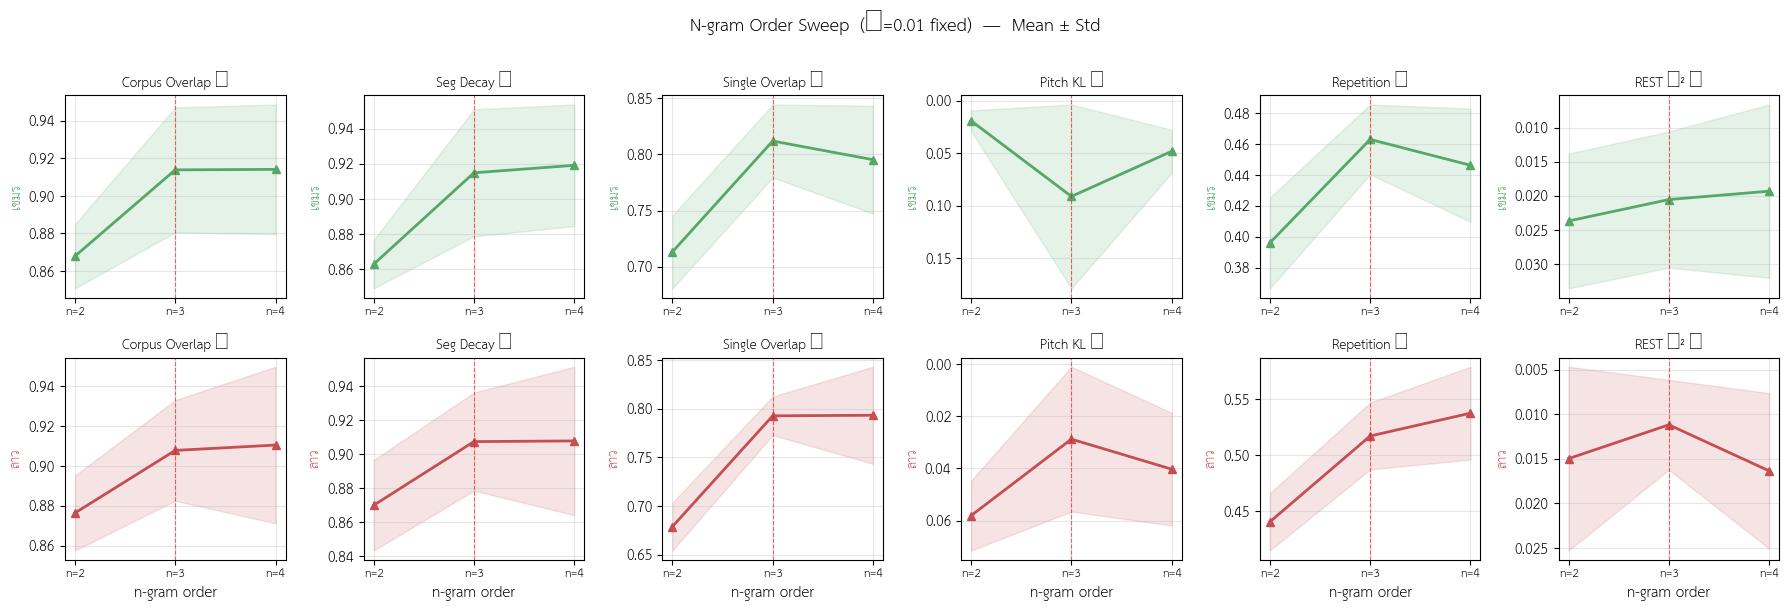

✅ Saved → fig_ngram_n_sweep.png


In [15]:
def plot_sweep_ngram_n(df, ax_row, alpha_fixed=0.01, color="#55A868"):
    d = df[df["alpha"] == alpha_fixed]
    ns = sorted(d["n"].unique())
    grp   = d.groupby("n")[METRICS]
    means = grp.mean()
    stds  = grp.std(ddof=1).fillna(0)
    for idx, m in enumerate(METRICS):
        ax = ax_row[idx]
        mu  = means[m].values
        sig = stds[m].values
        ax.plot(ns, mu, marker="^", linewidth=2, color=color)
        ax.fill_between(ns, mu - sig, mu + sig, alpha=0.15, color=color)
        ax.axvline(3, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
        ax.set_title(METRIC_LABELS[m], fontsize=9)
        ax.set_xticks(ns)
        ax.set_xticklabels([f"n={n}" for n in ns], fontsize=8)
        ax.grid(alpha=0.3)
        if m in LOWER_BETTER:
            ax.invert_yaxis()

fig, axes = plt.subplots(2, 6, figsize=(18, 6), sharey=False)
fig.suptitle("N-gram Order Sweep  (α=0.01 fixed)  —  Mean ± Std",
             fontsize=12, fontweight="bold", y=1.01)

plot_sweep_ngram_n(df_kn, axes[0], color="#55A868")
plot_sweep_ngram_n(df_ln, axes[1], color="#C44E52")

for j, m in enumerate(METRICS):
    axes[0][j].set_ylabel("เขมร", fontsize=9, color="#55A868")
    axes[1][j].set_ylabel("ลาว",   fontsize=9, color="#C44E52")
    axes[1][j].set_xlabel("n-gram order")

plt.tight_layout()
plt.savefig("fig_ngram_n_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_ngram_n_sweep.png")

### Figure 4 — Side-by-Side Bar Chart: 4 Models × 6 Metrics

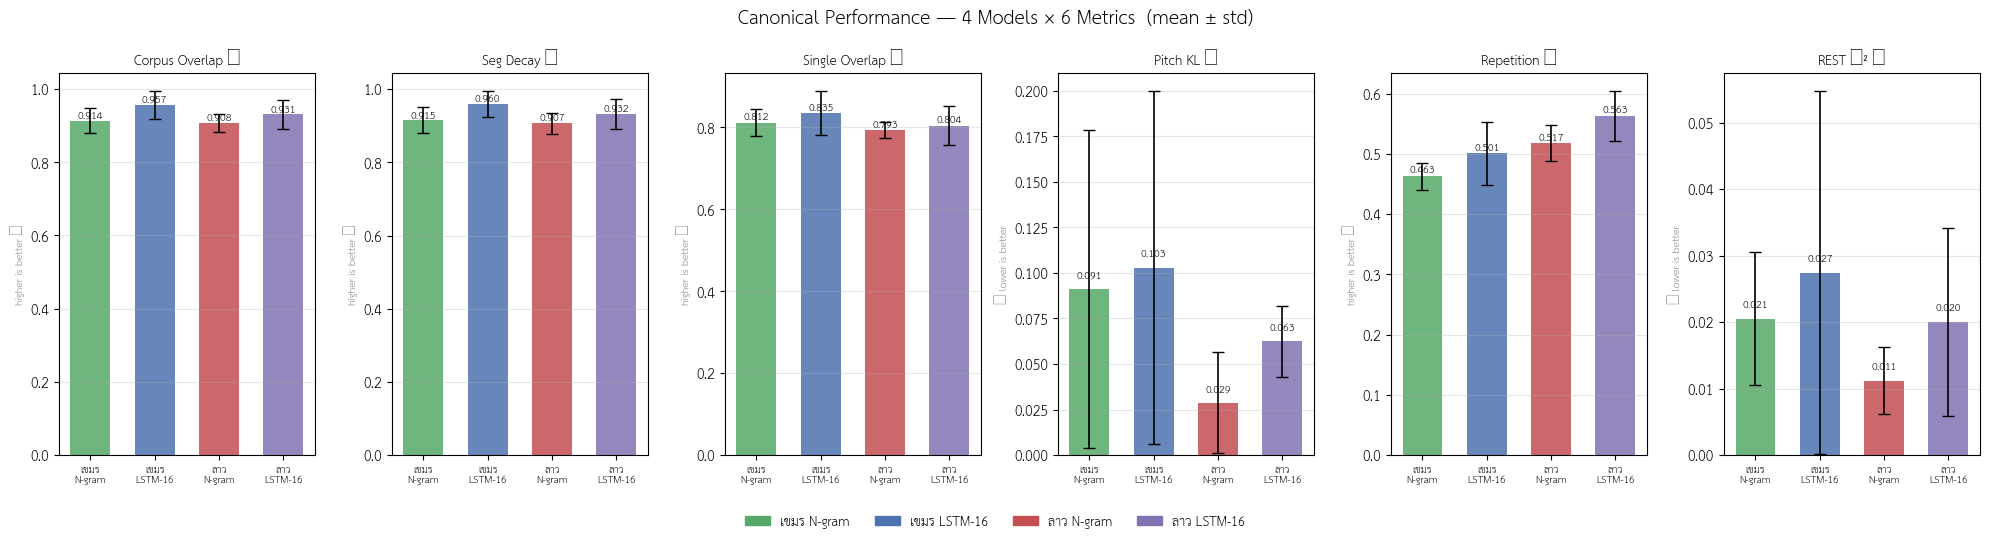

✅ Saved → fig_bar_4models.png


In [16]:
MODEL_COLORS = {
    "เขมร N-gram":  "#55A868",
    "เขมร LSTM-16": "#4C72B0",
    "ลาว N-gram":   "#C44E52",
    "ลาว LSTM-16":  "#8172B2",
}

x = np.arange(len(MAIN_MODELS))
width = 0.62
fig, axes = plt.subplots(1, 6, figsize=(20, 5))
fig.suptitle("Canonical Performance — 4 Models × 6 Metrics  (mean ± std)",
             fontsize=13, fontweight="bold")

for i, m in enumerate(METRICS):
    ax = axes[i]
    vals = [stats[model].loc[m, "mean"] for model in MAIN_MODELS]
    errs = [stats[model].loc[m, "std"]  for model in MAIN_MODELS]
    colors = [MODEL_COLORS[model] for model in MAIN_MODELS]
    bars = ax.bar(x, vals, width=width, color=colors, alpha=0.85, yerr=errs,
                  capsize=4, error_kw={"linewidth": 1.2})
    # Annotate bars with values
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(errs) * 0.05,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
    ax.set_title(METRIC_LABELS[m], fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(" ", "\n") for m in MAIN_MODELS], fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    if m in LOWER_BETTER:
        ax.set_ylabel("← lower is better", fontsize=7, color="grey")
    else:
        ax.set_ylabel("higher is better →", fontsize=7, color="grey")

# Legend
patches = [mpatches.Patch(color=MODEL_COLORS[m], label=m) for m in MAIN_MODELS]
fig.legend(handles=patches, loc="lower center", ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.08), frameon=False)
plt.tight_layout()
plt.savefig("fig_bar_4models.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_bar_4models.png")

### Figure 5 — Radar / Spider Chart: 4 Models

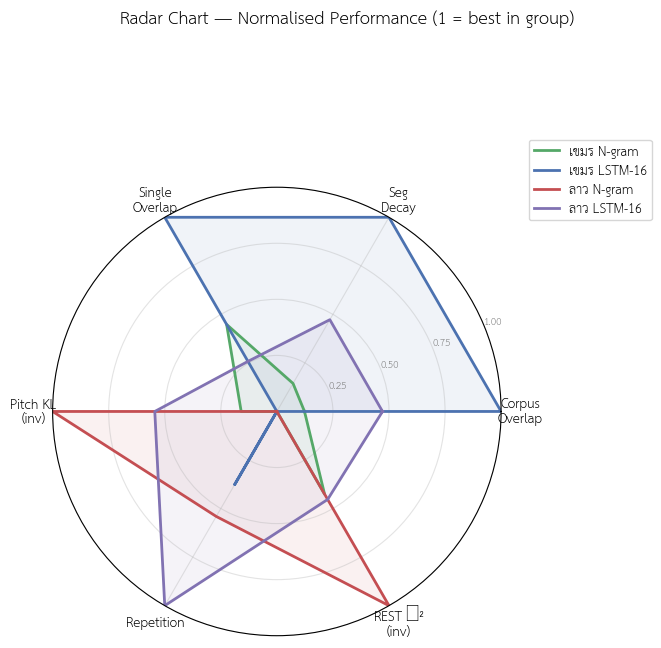

✅ Saved → fig_radar_4models.png


In [17]:
# For radar: normalise each metric to [0,1] where 1 = best possible
# Lower-is-better metrics are inverted so "higher = better" always applies.
def normalise_for_radar(stats_dict, models):
    """Return dict[model → list[0..1]] for radar plot, 6 metrics."""
    raw = {model: [stats_dict[model].loc[m, "mean"] for m in METRICS] for model in models}
    raw_df = pd.DataFrame(raw, index=METRICS).T  # shape (n_models, n_metrics)

    norm_df = raw_df.copy()
    for m in METRICS:
        col = raw_df[m]
        mn, mx = col.min(), col.max()
        if mx == mn:
            norm_df[m] = 1.0
        elif m in LOWER_BETTER:
            # invert: lower raw → higher normalised score
            norm_df[m] = (mx - col) / (mx - mn)
        else:
            norm_df[m] = (col - mn) / (mx - mn)
    return norm_df

norm_df = normalise_for_radar(stats, MAIN_MODELS)

# Radar labels (clean short)
radar_labels = ["Corpus\nOverlap", "Seg\nDecay", "Single\nOverlap",
                "Pitch KL\n(inv)", "Repetition", "REST χ²\n(inv)"]

N_AXES = len(METRICS)
angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — Normalised Performance (1 = best in group)",
             fontsize=12, fontweight="bold", y=1.01)

for model in MAIN_MODELS:
    vals = norm_df.loc[model].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, linewidth=2, color=MODEL_COLORS[model], label=model)
    ax.fill(angles, vals, alpha=0.08, color=MODEL_COLORS[model])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="grey")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.35)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=9)
plt.tight_layout()
plt.savefig("fig_radar_4models.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_radar_4models.png")

### Appendix — เขมร LSTM: seq_len=16 vs seq_len=32 (T=1.0)

seq_len ablation (เขมร LSTM, T=1.0):
                     Corpus Overlap ↑     Seg Decay ↑ Single Overlap ↑      Pitch KL ↓    Repetition ↑       REST χ² ↓
Model                                                                                                                 
เขมร LSTM-16 (T=1.0)   0.9573 ± 0.038  0.9598 ± 0.036   0.8351 ± 0.054  0.1030 ± 0.097  0.5008 ± 0.052  0.0274 ± 0.027
เขมร LSTM-32 (T=1.0)   0.9333 ± 0.042  0.9362 ± 0.042   0.8272 ± 0.048  0.0822 ± 0.085  0.4828 ± 0.035  0.0322 ± 0.030


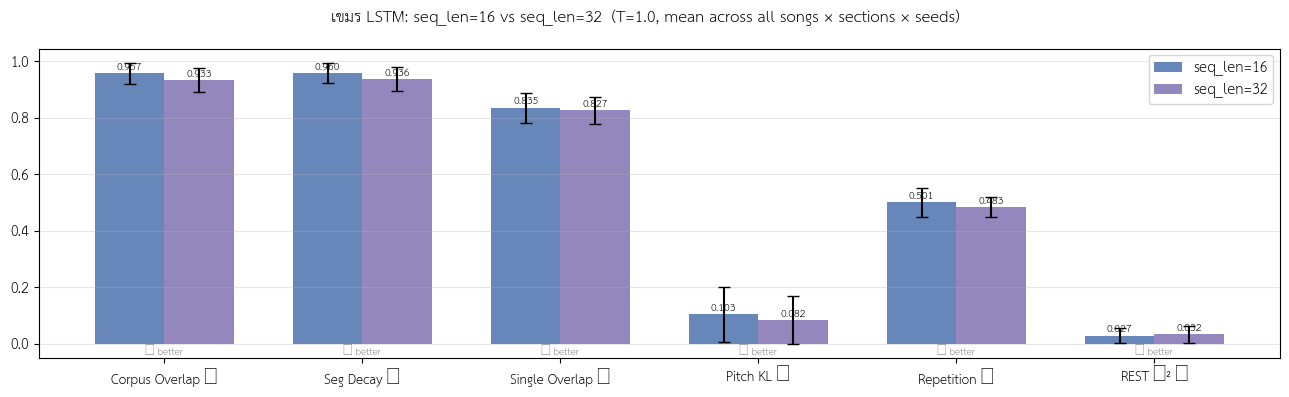

✅ Saved → fig_seqlen_ablation.png

Δ = seq_len-16 minus seq_len-32 (positive = 16 wins for ↑ metrics):


,seq_len-16,seq_len-32,Δ (16-32),winner
Corpus Overlap ↑,0.9573,0.9333,0.024,16
Seg Decay ↑,0.9598,0.9362,0.0236,16
Single Overlap ↑,0.8351,0.8272,0.0079,16
Pitch KL ↓,0.103,0.0822,0.0208,32
Repetition ↑,0.5008,0.4828,0.0179,16
REST χ² ↓,0.0274,0.0322,-0.0048,16


In [18]:
# ── seq_len 16 vs 32 table ────────────────────────────────────────────────────
sl_stats = {
    "เขมร LSTM-16 (T=1.0)": stats["เขมร LSTM-16"],
    "เขมร LSTM-32 (T=1.0)": stats["เขมร LSTM-32"],
}
rows_sl = {}
for label, s in sl_stats.items():
    row = {}
    for m in METRICS:
        row[METRIC_LABELS[m]] = f"{s.loc[m,'mean']:.4f} ± {s.loc[m,'std']:.3f}"
    rows_sl[label] = row

sl_table = pd.DataFrame(rows_sl).T
sl_table.index.name = "Model"

print("seq_len ablation (เขมร LSTM, T=1.0):")
print(sl_table.to_string())

# ── Bar chart: seq_len comparison ─────────────────────────────────────────────
x = np.arange(len(METRICS))
width = 0.35
fig, ax = plt.subplots(figsize=(13, 4))
fig.suptitle("เขมร LSTM: seq_len=16 vs seq_len=32  (T=1.0, mean across all songs × sections × seeds)",
             fontsize=11, fontweight="bold")

vals16 = [stats["เขมร LSTM-16"].loc[m, "mean"] for m in METRICS]
errs16 = [stats["เขมร LSTM-16"].loc[m, "std"]  for m in METRICS]
vals32 = [stats["เขมร LSTM-32"].loc[m, "mean"] for m in METRICS]
errs32 = [stats["เขมร LSTM-32"].loc[m, "std"]  for m in METRICS]

bars16 = ax.bar(x - width/2, vals16, width, label="seq_len=16", color="#4C72B0",
                alpha=0.85, yerr=errs16, capsize=4)
bars32 = ax.bar(x + width/2, vals32, width, label="seq_len=32", color="#8172B2",
                alpha=0.85, yerr=errs32, capsize=4)

for bar, v in zip(list(bars16) + list(bars32), vals16 + vals32):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([METRIC_LABELS[m] for m in METRICS], fontsize=9)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

# Annotate which direction is better
for i, m in enumerate(METRICS):
    direction = "↑ better" if m in HIGHER_BETTER else "↓ better"
    ax.text(i, 0.01, direction, ha="center", fontsize=6.5, color="grey",
            transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig("fig_seqlen_ablation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_seqlen_ablation.png")

# ── Numeric delta table ───────────────────────────────────────────────────────
print("\nΔ = seq_len-16 minus seq_len-32 (positive = 16 wins for ↑ metrics):")
deltas = {}
for m in METRICS:
    v16 = stats["เขมร LSTM-16"].loc[m, "mean"]
    v32 = stats["เขมร LSTM-32"].loc[m, "mean"]
    delta = v16 - v32
    winner = "16" if (delta > 0 and m in HIGHER_BETTER) or (delta < 0 and m in LOWER_BETTER) else "32"
    deltas[METRIC_LABELS[m]] = {"seq_len-16": round(v16, 4), "seq_len-32": round(v32, 4),
                                 "Δ (16-32)": round(delta, 4), "winner": winner}
pd.DataFrame(deltas).T

### Figure 6 — Per-Song Breakdown: Corpus Overlap & Repetition at Canonical Settings

In [ ]:
# Canonical filtered DataFrames for per-song analysis
canon = {
    "เขมร N-gram":  df_kn[(df_kn["n"] == 3) & (df_kn["alpha"] == 0.01)],
    "เขมร LSTM-16": df_kl16[df_kl16["temperature"] == 1.0],
    "ลาว N-gram":   df_ln[(df_ln["n"] == 3) & (df_ln["alpha"] == 0.01)],
    "ลาว LSTM-16":  df_ll16[df_ll16["temperature"] == 1.0],
}

focus_metrics = ["corpus_overlap", "repetition_score"]
fig, axes = plt.subplots(len(focus_metrics), 2, figsize=(16, 9))
fig.suptitle("Per-Song Breakdown at Canonical Settings — Corpus Overlap & Repetition",
             fontsize=12, fontweight="bold")

motif_pairs = [
    ("เขมร",  "เขมร N-gram",  "เขมร LSTM-16"),
    ("ลาว",   "ลาว N-gram",   "ลาว LSTM-16"),
]

for col_idx, (motif, ngram_key, lstm_key) in enumerate(motif_pairs):
    for row_idx, m in enumerate(focus_metrics):
        ax = axes[row_idx][col_idx]
        for label, color, ls in [(ngram_key, "#55A868" if motif == "เขมร" else "#C44E52", "o-"),
                                  (lstm_key,  "#4C72B0" if motif == "เขมร" else "#8172B2", "s--")]:
            per_song = canon[label].groupby("song")[m].mean()
            songs_sorted = sorted(per_song.index, key=lambda x: per_song[x], reverse=True)
            ax.barh(songs_sorted, [per_song[s] for s in songs_sorted],
                    color=color, alpha=0.7, label=label, height=0.35,
                    left=[0] * len(songs_sorted))
        ax.set_title(f"{motif}  —  {METRIC_LABELS[m]}", fontsize=9)
        ax.set_xlabel(METRIC_LABELS[m])
        ax.legend(fontsize=8)
        ax.grid(axis="x", alpha=0.3)
        ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig("fig_persong_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved → fig_persong_breakdown.png")

### Table 2 — Optimum Hyperparameter Search (Best α / Best T per metric)

In [ ]:
def best_hyperparam_table(df, model_type, hyperparam, hp_values, motif_label):
    """Find best hyperparameter value per metric (average across all songs/sections/seeds)."""
    rows = {}
    for hp_val in hp_values:
        if model_type == "lstm":
            subset = df[df["temperature"] == hp_val]
        else:
            # For N-gram: fix n=3, vary alpha
            subset = df[(df["n"] == 3) & (df["alpha"] == hp_val)]
        rows[f"{hyperparam}={hp_val}"] = {m: subset[m].mean() for m in METRICS}

    hp_df = pd.DataFrame(rows, index=METRICS).T
    hp_df.index.name = hyperparam

    # Find best per metric
    best_row = {}
    for m in METRICS:
        col = hp_df[m]
        best_val = col.min() if m in LOWER_BETTER else col.max()
        best_hp  = col.idxmin() if m in LOWER_BETTER else col.idxmax()
        best_row[m] = f"{best_hp}  ({best_val:.4f})"

    best_df = pd.DataFrame(best_row, index=["Best"]).rename(columns=METRIC_LABELS)
    full_df = hp_df.rename(columns=METRIC_LABELS).round(4)
    return full_df, best_df

print("=" * 80)
print("LSTM Temperature — เขมร")
print("=" * 80)
kl_full, kl_best = best_hyperparam_table(df_kl16, "lstm", "T", [0.8, 1.0, 1.1, 1.3], "เขมร")
display(kl_full)
display(kl_best)

print("\n" + "=" * 80)
print("LSTM Temperature — ลาว")
print("=" * 80)
ll_full, ll_best = best_hyperparam_table(df_ll16, "lstm", "T", [0.8, 1.0, 1.1, 1.3], "ลาว")
display(ll_full)
display(ll_best)

print("\n" + "=" * 80)
print("N-gram α (n=3) — เขมร")
print("=" * 80)
kn_full, kn_best = best_hyperparam_table(df_kn, "ngram", "α", [0.001, 0.01, 0.1, 1.0], "เขมร")
display(kn_full)
display(kn_best)

print("\n" + "=" * 80)
print("N-gram α (n=3) — ลาว")
print("=" * 80)
ln_full, ln_best = best_hyperparam_table(df_ln, "ngram", "α", [0.001, 0.01, 0.1, 1.0], "ลาว")
display(ln_full)
display(ln_best)

---

## 📋 Executive Summary (auto-generated from data)

---

## 🔗 How Stage 2 Connects to Generation (the Bridging Rationale)

This is the intellectual spine that links the classification work to the generation work.  
Keep this framing in your defence — it shows the two stages are not separate contributions but a single designed system.

---

### The Core Idea

Stage 2 does one thing: it builds a **style-fingerprint space**.  
V1→V5 are progressively richer ways to describe *what a fragment sounds like*, and the classifier learns where the motif boundaries sit in that space.

That same space has two downstream uses in Stage 3:

```
 NEW FRAGMENT (unlabeled)
       │
       ▼
  Project into V5 space
       │
       ├──► Cosine / LogReg → assigns motif identity (เขมร / ลาว / แขก)
       │         → used as the GENERATION CONDITION (Stage 3 input)
       │
       └──► Distance to motif centroid
                 → used as the STYLE CONSISTENCY SCORE (Stage 3 evaluation)
```

Stage 2 teaches the system *what each style looks like*.  
Stage 3 *uses* that knowledge — both to steer generation and to evaluate its outputs.

---

### Application 1 — Categorising New/Unlabeled Songs

**Problem:** A newly discovered piece (or a newly transcribed song) has no motif label.  
The system can automatically assign one.

- Extract 32-slot fragments from the new piece
- Compute V5 feature vector for each fragment
- Run the LogReg classifier (87% accuracy, 3-class) → majority vote across fragments → motif identity

**Why this matters for generation:**  
The generation models (LSTM, future Transformer/Mamba) are all *class-conditioned* — they were trained separately per motif.  
Without a motif identity, you cannot pick which model to use, or which corpus to condition on.  
The Stage 2 classifier *unlocks* the generation pipeline for unlabeled inputs.

---

### Application 2 — Feature Vector as Generation Condition (soft conditioning)

Currently, generation is conditioned on a **hard label** (`"generate เขมร"`).  
With the feature space available, you can condition on the **actual feature vector** of the seed fragment — a *soft* condition.

- A seed that is 90% เขมร / 10% ลาว in feature space → blend the two generation distributions accordingly
- This allows **style interpolation**: generate music that gradually transitions from one motif style to another
- Practical: useful for pieces that genuinely straddle two styles (e.g., some จีนเขมร hybrid pieces)

> This is future work — but the infrastructure (feature vectors + trained classifier) already exists in Stage 2.  
> It is worth one slide bullet: *"Feature space from Stage 2 enables continuous style conditioning as a direct extension."*

---

### Application 3 — Feature Vector as Generation Evaluator (the cleanest link)

**Current evaluation metrics** measure surface-level similarity:
- N-gram overlap → did the generator reproduce the same sequences?
- KL divergence → does the pitch distribution match?

**Feature-vector distance** measures *stylistic identity*:

> After generating a continuation, compute its V5 feature vector and measure cosine distance to the target motif centroid.  
> Call this the **Style Centroid Distance (SCD)** metric.

| Generated output | SCD interpretation |
|---|---|
| Close to เขมร centroid | Stylistically appropriate for the conditioning motif ✅ |
| Closer to ลาว centroid | Style drift — generator "drifted" into a different motif's vocabulary ⚠️ |
| Far from all centroids | Incoherent — not recognisable as any motif ❌ |

This turns the Stage 2 classifier into a **style judge** for Stage 3.  
It is a more meaningful metric than raw n-gram overlap, because it evaluates *style identity* rather than *literal token repetition*.

---

### The One-Paragraph Framing for Your Defence/Thesis

> *"The feature vectors constructed in Stage 2 serve a dual role. During analysis, they encode motif identity, enabling classification of unlabeled fragments at 87% accuracy (LogReg V5). During generation, the same vectors provide two services: first, they act as the input-side style condition — any new fragment can be automatically assigned a motif class before passing it to the class-conditioned generator; second, they act as the output-side style evaluator — the cosine distance from a generated fragment to its target motif centroid quantifies how well the generator preserved the conditioning style. This creates a closed loop: Stage 2 defines the style space, and Stage 3 operates within it."*

---

### Summary Table for a Slide

| Role | Stage 2 component used | In Stage 3 |
|---|---|---|
| **Categorise new input** | LogReg V5 classifier | Assign motif → choose generation model |
| **Set generation target** | Motif centroid (hard or soft) | Class condition or blended interpolation |
| **Evaluate generated output** | Cosine distance to centroid | Style Centroid Distance metric |
| **Detect style drift** | Distance from all centroids | Quality gate (warn if SCD > threshold) |

---

## 🗂️ Taxonomy of New Songs — How the System Handles Each Case

When you encounter a new piece of music, it falls into one of four categories.  
The feature space from Stage 2 handles each differently — and unsupervised methods like K-means are actually essential for cases 3 and 4.

---

### Case 1 — Unlabeled (no tag at all)

*"Someone hands you a MIDI file with no name or style information."*

**What to do:**
1. Extract fragments → compute V5 feature vectors
2. **Option A (supervised):** Run LogReg V5 → assigns fragment-level motif predictions → majority vote = song-level motif label
3. **Option B (unsupervised):** Project V5 vectors into 2D PCA/UMAP → visually inspect which existing cluster they fall into

**Confidence check:** If all fragments vote the same class → high confidence assignment.  
If fragments split 60/40 between two classes → flag as ambiguous → treat as Case 3.

---

### Case 2 — Labeled, single motif (clean ground truth)

*"Song has a name, and it clearly belongs to one style family (e.g., เขมรไทรโยค → เขมร)."*

This is the easy case. The label is used directly:
- As training data for the generation model
- As a verification test: run the classifier on it — does it agree with the human label?  
  If the classifier *disagrees*, it raises a musicological question worth investigating.

> **This is also how you validate the classifier** — if it consistently disagrees with human labels on well-known pieces, either the features (V1–V5) are missing something important, or the human labeling convention is inconsistent.

---

### Case 3 — Labeled, but mixed motifs

*"The song has a name and style tag, but it contains passages from multiple motif families — e.g., a piece that opens เขมร and transitions to ลาว."*

This is common in Thai classical music (เถา pieces especially).  
A **song-level label is wrong here** — the label should be at the **fragment level**.

**How the feature space reveals this:**

Run K-means (k=3 or k=number of known motifs) on the V5 vectors of all fragments from this song.  
If the fragments split cleanly into two or more clusters that each align with a different known motif centroid → the song is **structurally mixed**.

```
Fragment-level K-means result for a mixed piece:
  Cluster A: bars 1–12  → centroid near เขมร  
  Cluster B: bars 13–24 → centroid near ลาว  
```

**Implication for generation:**  
- Don't use a single model to generate the whole piece
- Segment by cluster → use the เขมร model for bars 1–12, ลาว model for 13–24
- The transition point between clusters becomes a **structural seam** — the generator switches models there

---

### Case 4 — Labeled, but NOT a motif piece

*"The song has a Thai name but doesn't belong to any recognized motif family — it's either a unique composition (เพลงตับ, ceremonial), or it genuinely sits outside the เขมร/ลาว/แขก taxonomy."*

This is the **out-of-distribution (OOD)** case, and it's the most interesting one.

**How to detect it:**

After projecting into V5 space, compute the distance from the fragment to **all** known motif centroids.  
If *all* distances are large → OOD.

Define a threshold: if `min(cosine_dist_to_all_centroids) > θ`, the fragment is OOD.  
(θ can be calibrated as, e.g., the 95th percentile of intra-class distances from the training set.)

**What to do with OOD pieces:**
- **Option A:** Leave them out of supervised training (they would add noise)
- **Option B:** Use K-means to cluster OOD fragments together → discover if they form a coherent new stylistic cluster → potentially define a **new motif class** (data-driven motif discovery)
- **Option C:** For generation, interpolate between the two nearest centroids as a soft condition — the model generates in a "blend zone"

---

### Where K-means Fits In — Unsupervised Role Summary

K-means (and UMAP/PCA visualization) is not a *replacement* for the LogReg classifier — it plays a **complementary diagnostic role**:

| Task | Supervised (LogReg V5) | Unsupervised (K-means / UMAP) |
|---|---|---|
| Assign a label to a clean new song | ✅ Primary method | Backup visualization |
| Detect mixed-motif structure within a song | ❌ Only gives one label per fragment | ✅ Reveals within-song cluster splits |
| Detect OOD (not-a-motif) pieces | ⚠️ Will force-assign nearest class | ✅ Shows up as isolated cluster or noise |
| Discover new motif classes from unlabeled corpus | ❌ Requires predefined classes | ✅ Primary method |
| Validate human musicological labels | ✅ Agreement rate = validation metric | ✅ Visual cluster alignment |

---

### The Decision Tree for a New Song

```
New piece arrives
       │
       ▼
Extract V5 vectors for all fragments
       │
       ├── All fragments cluster tightly → near ONE known centroid?
       │         YES → Case 2/1: Assign that motif label (supervised)
       │
       ├── Fragments split into MULTIPLE known-centroid clusters?
       │         YES → Case 3: Mixed motif — segment by cluster, multi-model generation
       │
       ├── All fragments far from ALL known centroids?
       │         YES → Case 4: OOD — either new motif class or unique piece
       │                         → K-means on OOD pool → discover new cluster?
       │
       └── Fragments scattered with no clear cluster?
                 → Likely transcription noise or highly experimental piece
                 → Flag for manual review
```

---

### One-liner for the defence

> *"The V5 feature space gives us a principled way to handle any new piece regardless of its label quality: supervised classification for clean inputs, K-means segmentation for mixed-motif pieces, and centroid-distance thresholding for out-of-distribution detection — the same feature space that enables generation also enables quality control over the inputs to the generator."*